In [23]:
import pandas as pd

# Load dataset
df = pd.read_csv("kc_house_data.csv")

# Preview data
df.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [24]:

# Drop date column (not useful directly)
target="price"
X = df.drop(columns=["price", "date"])
y = df["price"]

# If price is continuous, convert to classification (example)
y = (y > y.median()).astype(int)   # High price vs Low price



In [25]:
# Numerical features
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical features
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:", numerical_features)
print("Categorical Features:", categorical_features)


Numerical Features: ['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
Categorical Features: []


In [26]:
from sklearn.impute import SimpleImputer

# Imputer for numerical features
num_imputer = SimpleImputer(strategy="median")

# Imputer for categorical features
cat_imputer = SimpleImputer(strategy="most_frequent")


In [27]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(handle_unknown="ignore")


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_imputer, numerical_features),
        ("cat", Pipeline([
            ("imputer", cat_imputer),
            ("encoder", cat_encoder)
        ]), categorical_features)
    ]
)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (17290, 19)
Testing set size: (4323, 19)


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}


In [33]:
results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc


In [ ]:
print("Base Model Performance (Accuracy):\n")

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")


Base Model Performance (Accuracy):

Logistic Regression: 0.4941
Decision Tree: 0.8718
KNN: 0.7724
Random Forest: 0.9174


In [34]:
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score


In [35]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

meta_train = np.zeros((X_train.shape[0], len(models)))
meta_test = np.zeros((X_test.shape[0], len(models)))


In [37]:
for i, (name, model) in enumerate(models.items()):
    
    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        meta_train[val_idx, i] = model.predict(X_val)

    # Train on full training set and predict test set
    model.fit(X_train, y_train)
    meta_test[:, i] = model.predict(X_test)


In [38]:
meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(meta_train, y_train)


LogisticRegression(max_iter=1000)

In [39]:
stacked_pred = meta_model.predict(meta_test)

stacking_accuracy = accuracy_score(y_test, stacked_pred)

print("Stacking Model Accuracy:", stacking_accuracy)


Stacking Model Accuracy: 0.9174184594031922


In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [41]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best Individual Model:", best_model_name)


Best Individual Model: Random Forest


In [42]:
# Predict using best base model
best_pred = best_model.predict(X_test)

# Accuracy
best_accuracy = accuracy_score(y_test, best_pred)
print("Best Model Accuracy:", best_accuracy)


Best Model Accuracy: 0.9174184594031922


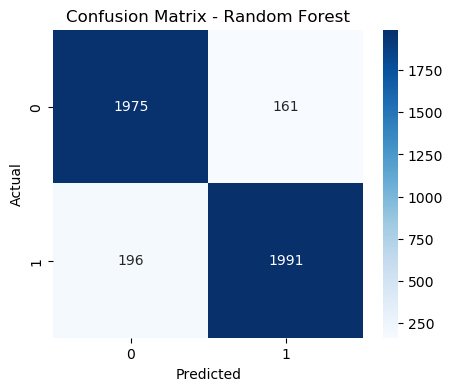

In [43]:
cm_best = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [44]:
# Accuracy
stack_accuracy = accuracy_score(y_test, stacked_pred)
print("Stacking Model Accuracy:", stack_accuracy)


Stacking Model Accuracy: 0.9174184594031922


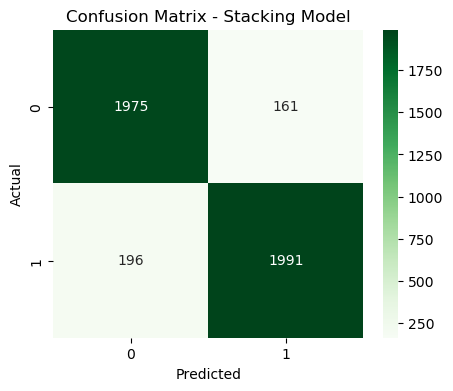

In [45]:
cm_stack = confusion_matrix(y_test, stacked_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_stack, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Stacking Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
